# Enriched Heatmaps and identification of regions with different activities

## Learning objectives

- Distinguish between when to use `Heatmap()` and `HeatmapAnnotation()`
- Generate row split annotations for enriched heatmaps
- Add multiple categorical annotations with separate color legends
- Avoid common data handling errors in heatmap plotting

## Loading libraries

In this exercise, we shall use methods from the `gUtils` library. It provides a set of utility functions for use with GenomicRanges. We need to install it properly in the current environment [following the author's instructions](https://github.com/mskilab-org/gUtils).

In [ ]:
suppressPackageStartupMessages(suppressWarnings({
  library(SummarizedExperiment)
  library(GenomicRanges)
  library(gUtils)
  library(rtracklayer)
  library(EnrichedHeatmap)
  library(ComplexHeatmap)
}))

## Preparing the ATAC `SummarizedExperiment`

Here we load the `SummarizedExperiment` for the ATAC-seq data

In [2]:
atac <- readRDS("data/atac_se.rds")

### ATAC peaks information

Each peak region represent the activity in a genomic region. These peaks are annotated for various features, including their genomic annotations and the results for differential accessibility analysis is also added there.

In [3]:
rd_atac <- rowRanges(atac)

rd_atac

GRanges object with 3656 ranges and 18 metadata columns:
         seqnames              ranges strand |             annotation   geneChr
            <Rle>           <IRanges>  <Rle> |            <character> <integer>
     [1]     chr1     3670547-3672665      * |       Promoter (<=1kb)         1
     [2]     chr1     4332510-4332710      * | Intron (ENSMUST00000..         1
     [3]     chr1     4491755-4492573      * |       Promoter (1-2kb)         1
     [4]     chr1     4571186-4572423      * |      Distal Intergenic         1
     [5]     chr1     4785062-4786325      * |       Promoter (<=1kb)         1
     ...      ...                 ...    ... .                    ...       ...
  [3652]     chr2 181764664-181764891      * |       Promoter (1-2kb)         2
  [3653]     chr2 181766881-181767875      * |       Promoter (<=1kb)         2
  [3654]     chr2 181837244-181838655      * |       Promoter (<=1kb)         2
  [3655]     chr2 181863853-181865066      * |       Promoter (

Once we have the short sequencing reads in an ATAC-seq experiment, bioinformatics algorithms take over to recreate the biological landscape of the genomic accessibity.

* **Alignment:** We take every read and match it to a reference genome to find exactly where it originated.
* **Generating Coverage:** When thousands of reads map to the exact same open genomic location, they form a "pile-up." This is the black, mountainous signal we see in the example snapshot of chromatin accessibility.
* **Peak Calling:** We use statistical algorithms (like *MACS2*) to distinguish true biological pile-ups from random background noise, artifacts and duplicates. The algorithm defines the precise boundaries of these pile-ups, creating discrete peak regions (the shaded boxes on the example snapshot of chromatin accessibility) with specific coordinates (e.g., `chr1`, `start: 100`, `end: 400`).

### Statistical results

Now that we have genomic coordinates for our peaks, we can extract the specific information:

* Genomic annotation: we compare our peak coordinates against a known database of genes. This tells us which gene is nearby (e.g., `Gene1`) and how far the peak is from the Transcription Start Site (`distanceTSS`).
* Differential accessibility: to compare conditions, we count exactly how many sequencing reads fall within a specific peak region for each experimental group (e.g., `Group1` vs `Group2`). Statistical software (like *DESeq2*) then calculates the **fold-change (FC)** between these counts to determine if a region *significantly* opened or closed in response to a treatment.

### From BAM files to differential peaks

Here is the step-by-step bioinformatics pipeline used to generate those exact values from the raw data:

1. Creating a cnsensus peak set: to compare the samples, bioinformatics tools merge all the individual peak files across all replicates and conditions into a single "master list" of non-overlapping genomic windows. This ensures we are comparing the exact same spatial coordinates across the board.
2. Generating the count matrix: once the master list of regions is defined, we go back to the original aligned sequence alignments (the BAM files). Using tools like _featureCounts_ or _bedtools_, we count exactly how many reads fall into each consensus region for every single sample. This generates a large matrix where the rows are the genomic regions and the columns are the individual samples.
3. Statistical modeling: this raw count matrix is then fed into differential expression software, most commonly DESeq2 or edgeR.
   - **Normalization:** the software mathematically adjusts for differences in sequencing depth between the samples.
   - **Testing:** it fits a negative binomial model to test if the difference in read counts between groups (e.g., Group 1 vs. Group 2) is statistically significant.
   - **Output:** the algorithm outputs a results table containing the Log₂ fold-change (`logFC`), p-values, and adjusted p-values for every single region.
4. Constructing the `rowRanges`: finally, the data is assembled for visualization tools like `EnrichedHeatmap`, which relies on the Bioconductor ecosystem. The genomic coordinates (`chr`, `start`, `end`) form the core of the `rowRanges` object, and the statistical results (like the `logFC` and p-values) are tacked on as metadata columns. This creates a unified object where the visualization tool instantly knows both *where* the region is located and *how significantly* its accessibility changed.

### Filtering the dataset

Based on standard bioinformatics practices, we want to filter for peaks that have a significant statistical change (*qvalue*) and a meaningful magnitude of change (*logFC*).

In [4]:
# qvalue is the FDR adjusted P value
#rd_atac <- rd_atac[abs(rd_atac$logFC) >= 0.5 & rd_atac$qvalue <= 0.1]
rd_atac_filtered = subset(rd_atac, abs(logFC) >= .5 & qvalue <= .1)

# Add an "ATAC_" prefix to all the metadata columns in rd_atac_filtered
colnames(elementMetadata(rd_atac_filtered)) <- paste(
  "ATAC", colnames(elementMetadata(rd_atac_filtered )), sep = "_")

Using the absolute value (`abs()`) is crucial here. It ensures we are keeping peaks that *gained* accessibility (logFC ≥ 0.5) AND peaks that *lost* accessibility (logFC ≤ -0.5). If we didn't use `abs()`, we would accidentally throw away all the regions that closed down!

In [5]:
rd_atac_filtered

GRanges object with 1933 ranges and 18 metadata columns:
         seqnames              ranges strand |        ATAC_annotation
            <Rle>           <IRanges>  <Rle> |            <character>
     [1]     chr1     3670547-3672665      * |       Promoter (<=1kb)
     [2]     chr1     4332510-4332710      * | Intron (ENSMUST00000..
     [3]     chr1     4491755-4492573      * |       Promoter (1-2kb)
     [4]     chr1     4571186-4572423      * |      Distal Intergenic
     [5]     chr1     4785062-4786325      * |       Promoter (<=1kb)
     ...      ...                 ...    ... .                    ...
  [1929]     chr2 181713633-181714134      * |       Promoter (<=1kb)
  [1930]     chr2 181714476-181715931      * |       Promoter (<=1kb)
  [1931]     chr2 181762779-181764180      * |       Promoter (<=1kb)
  [1932]     chr2 181764664-181764891      * |       Promoter (1-2kb)
  [1933]     chr2 181837244-181838655      * |       Promoter (<=1kb)
         ATAC_geneChr ATAC_geneSt

### ATAC-seq peak widths

Most of the peaks are around 1000 bp wide. We can check the distribution with a histogram.

Median peak width in the filtered dataset = 932 
99% percentile in the filtered dataset = 1985.88

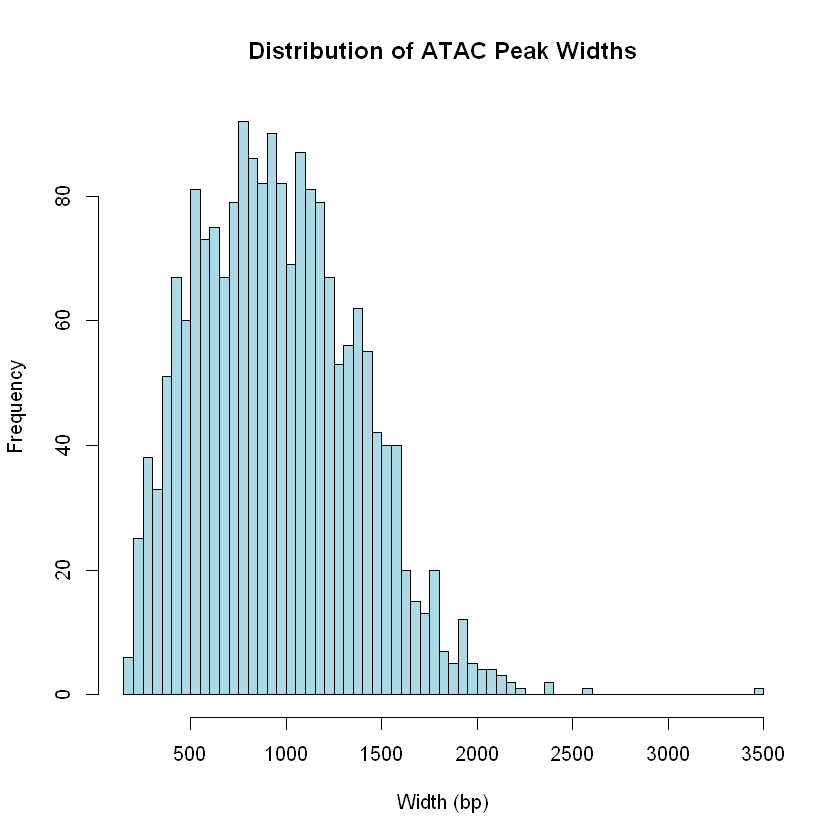

In [6]:
# median(lengths(rd_atac_filtered))  # `lengths` (plural) is an alias for `width`
cat(
  "Median peak width in the filtered dataset =",
  median(width(rd_atac_filtered)),
  '\n')

cat(
  "99% percentile in the filtered dataset =",
  quantile(width(rd_atac_filtered), .99))

hist(
  width(rd_atac_filtered),
  breaks = 50,
  main = "Distribution of ATAC Peak Widths",
  xlab = "Width (bp)",
  col = "lightblue",
  border = "black")

The rows in the `SummarizedExperiment` represent actual biological features—specifically, regions where the chromatin was physically open (peaks). Indeed, an open chromatin region (like a promoter or enhancer) is naturally a few hundred base pairs wide. However, to compare E11.5 and E15.5, we need to merge the peaks from all samples together to create a unified "master list" (a consensus peak set). When we merge overlapping peaks from multiple different samples, the resulting master regions naturally stretch out, averaging around ~1,000 bp to ensure they cover the entire open zone for all samples.

### Binning signal across a 2 kb window

For plotting the data, we can hence consider 1000 bp around the **peak-mid** that we find using `gr.mid()`, which returns the 1-bp center of each peak. It directly overwrites the data inside the `ranges` column.

In [7]:
# Finding mid of all peaks
mid_peaks <- gr.mid(rd_atac_filtered)

head(mid_peaks, 3)

GRanges object with 3 ranges and 18 metadata columns:
      seqnames    ranges strand |        ATAC_annotation ATAC_geneChr
         <Rle> <IRanges>  <Rle> |            <character>    <integer>
  [1]     chr1   3671606      * |       Promoter (<=1kb)            1
  [2]     chr1   4332610      * | Intron (ENSMUST00000..            1
  [3]     chr1   4492164      * |       Promoter (1-2kb)            1
      ATAC_geneStart ATAC_geneEnd ATAC_geneLength ATAC_geneStrand ATAC_geneId
           <integer>    <integer>       <integer>       <integer> <character>
  [1]        3214482      3671498          457017               2      497097
  [2]        4344146      4360314           16169               2       19888
  [3]        4492465      4493735            1271               2       20671
         ATAC_transcriptId ATAC_distanceToTSS       ATAC_ENSEMBL ATAC_SYMBOL
               <character>          <numeric>        <character> <character>
  [1] ENSMUST00000070533.4                  0 ENSMUS

### Finding peak centers with `resize()`

There actually is a native way to do this in standard `GenomicRanges`, but it doesn't have a dedicated _midpoint_ name. Instead, Bioconductor relies on its highly versatile `resize()` function.

In [8]:
# Finding mid of all peaks
mid_peaks <- resize(rd_atac_filtered, width = 1, fix = "center")

# adding names to peaks to give them identity
names(mid_peaks) <- paste("peak", 1:length(mid_peaks), sep = "_")

head(mid_peaks, 3)

GRanges object with 3 ranges and 18 metadata columns:
         seqnames    ranges strand |        ATAC_annotation ATAC_geneChr
            <Rle> <IRanges>  <Rle> |            <character>    <integer>
  peak_1     chr1   3671606      * |       Promoter (<=1kb)            1
  peak_2     chr1   4332610      * | Intron (ENSMUST00000..            1
  peak_3     chr1   4492164      * |       Promoter (1-2kb)            1
         ATAC_geneStart ATAC_geneEnd ATAC_geneLength ATAC_geneStrand
              <integer>    <integer>       <integer>       <integer>
  peak_1        3214482      3671498          457017               2
  peak_2        4344146      4360314           16169               2
  peak_3        4492465      4493735            1271               2
         ATAC_geneId    ATAC_transcriptId ATAC_distanceToTSS       ATAC_ENSEMBL
         <character>          <character>          <numeric>        <character>
  peak_1      497097 ENSMUST00000070533.4                  0 ENSMUSG00000051

As we saw in the previous notebook, a `GRanges` object is not a standard data frame. It strictly separates its data into two distinct parts: **Core Geometry** and **Metadata** . Because `GRanges` is an object-oriented structure (S4), we have to use specific "accessor" functions to extract the core geometry.

In [9]:
# Returns an IRanges object with start, end, and width
ranges(mid_peaks)

IRanges object with 1933 ranges and 0 metadata columns:
                start       end     width
            <integer> <integer> <integer>
     peak_1   3671606   3671606         1
     peak_2   4332610   4332610         1
     peak_3   4492164   4492164         1
     peak_4   4571804   4571804         1
     peak_5   4785693   4785693         1
        ...       ...       ...       ...
  peak_1929 181713883 181713883         1
  peak_1930 181715203 181715203         1
  peak_1931 181763479 181763479         1
  peak_1932 181764777 181764777         1
  peak_1933 181837949 181837949         1

_Note: Because `GRanges` is an S4 object, its core architecture is rigidly locked. we physically cannot add a custom geometry column (like midpeak) next to start and end. The rules of the object state that a `GRanges` row can only represent exactly one genomic interval at a time._

## Preparing the continuous bigWig data

### Loading data from bigWig

The SE aggregates the data into one single number per peak. All spatial information is destroyed. It cannot tell us if those 500 reads were tightly piled up exactly in the middle, or spread out evenly across the region.

A bigWig file contains the continuous, base-pair-by-base-pair signal coverage across the entire genome. To draw an `EnrichedHeatmap`, we don't want just one flat color for the whole peak. We want to see the actual biological shape of the chromatin accessibility (e.g., a sharp spike at the center, tapering off 1000 bp away).

bigWig files are compressed, indexed, binary format used for efficiently displaying continuous data, like genomic signal data, in genome browsers. Here, we read in ATAC-seq bigWig files, **filters** the data to specific chromosomes, normalizes signal intensity around genomic regions of interest (peak centers), and saves the resulting matrices for downstream visualization.

In [10]:
# Find all files in the "data" folder that contain "ATAC" in their name.
# full.names = TRUE ensures we get the full file path (e.g., "data/ATAC_11half.bw")
atac_files <- list.files("data", pattern = "ATAC", full.names = TRUE)

# Clean up the filenames to use as names for our list; basename() extracts just the filename 
# from the path; gsub() replaces the ".bw" extension with nothing (""), leaving a clean name.
names(atac_files) <- gsub(pattern = "\\.bw", replacement = "", x = basename(atac_files))

# Loop over every file in our list using lapply()
atac_bw <- lapply(atac_files, function(x){
  
  # Read the bigWig file from the hard drive into R as a GRanges object
  a <- rtracklayer::import(x)
  
  # Filter the GRanges object to ONLY keep data mapping to chr1 or chr2
  a <- a[seqnames(a) %in% c("chr1", "chr2")]
  
  # Return the filtered GRanges object to be saved in the atac_bw list
  return(a)
})

Here, we load the entire `.bw` file into memory using `rtracklayer::import(x)` and then filter it down to *chr1* and *chr2*. However, real-world whole-genome bigWig files can be massive and will crash a standard computer's RAM. To do this efficiently, we can pass a `Ranges` object to the `which=` argument of the `import()` function, for example, `import(x, which = my_regions)`. This forces R to dynamically extract only the data for those specific coordinates directly from the hard drive, saving huge amounts of memory and time.

In [11]:
atac_bw <- lapply(atac_files, function(x){

  # Peek at the file's index to get the lengths of the chromosomes
  bw_file <- rtracklayer::BigWigFile(x)
  genome_info <- seqinfo(bw_file)

  # Create a GRanges object representing the full length of chr1 and chr2
  # as() converts the Seqinfo object directly into a GRanges object spanning the chromosomes
  target_chrs <- as(genome_info[c("chr1", "chr2")], "GRanges")

  # Read ONLY chr1 and chr2 from the hard drive
  a <- rtracklayer::import(x, which = target_chrs)

  return(a)
})

Since the only reason we are loading this data is to draw a heatmap spanning 1000 bp up/downstream of our `mid_peaks`, we don't even need the rest of *chr1* and *chr2*. We can use our `mid_peaks` object to fetch only the exact 2000 bp windows we need, reducing the memory footprint from millions of rows per sample down to just a tiny fraction of that.

In [12]:
# Define the actual 2000 bp windows we need for the heatmap
heatmap_windows <- resize(mid_peaks, width = 2000, fix = "center")

atac_bw <- lapply(atac_files, function(x){

  # Read ONLY the 2000 bp windows around our peaks from the hard drive
  a <- rtracklayer::import(x, which = heatmap_windows)

  return(a)
})

When imported into R, each individual bigWig file is represented as a `GRanges` object. Because we loaded multiple files at once, our `atac_bw` variable is a list of `GRanges` objects.

In [13]:
atac_bw

$ATAC_11half
GRanges object with 72531 ranges and 1 metadata column:
          seqnames              ranges strand |     score
             <Rle>           <IRanges>  <Rle> | <numeric>
      [1]     chr1     3670606-3670650      * |  0.195004
      [2]     chr1     3670651-3670700      * |  0.176254
      [3]     chr1     3670701-3670750      * |  0.168754
      [4]     chr1     3670751-3670800      * |  0.303756
      [5]     chr1     3670801-3670850      * |  0.382508
      ...      ...                 ...    ... .       ...
  [72527]     chr2 181838651-181838700      * | 0.0262506
  [72528]     chr2 181838701-181838750      * | 0.0000000
  [72529]     chr2 181838751-181838800      * | 0.0412509
  [72530]     chr2 181838801-181838850      * | 0.0450010
  [72531]     chr2 181838851-181838948      * | 0.0112502
  -------
  seqinfo: 66 sequences from an unspecified genome

$ATAC_15half
GRanges object with 72127 ranges and 1 metadata column:
          seqnames              ranges strand 

In [14]:
cat(
  "Median width = ",
  median(width(atac_bw$ATAC_11half))
)

Median width =  50

Unlike the `SE` peaks, the rows in a bigWig file are artificial mathematical bins, not biological features.

To compress the file, the genome is artificially chopped into an invisible grid of 50 bp windows, likely using a tool like deepTools `bamCoverage` with a command like `--binSize 50`. The software calculates the average signal for that 50 bp window and saves it as a single chunk.

Note that there are some exceptions. bigWig uses a compression trick called "run-length encoding." If two consecutive 50 bp bins happen to have the exact same signal score, the bigWig file merges them into a single 100 bp row. And if a bin is completely empty (zero reads), it is completely deleted from the file to save space, which can cause the surrounding bins to look chopped or offset.

### Normalization

Next, we calculate the normalized signals into the area of interest.

In `EnrichedHeatmap`, the genomic region is chopped up into tiny windows (bins). The algorithm needs to calculate a single "average" signal for each bin. Because bigWig files are highly compressed, they completely omit regions that have zero reads.

For example, if a 20 bp bin has a signal of 10 covering 5 base pairs, and the bigWig file is "missing" data for the other 15 base pairs, w0 correctly assumes the missing data is zero. The `mean_mode = "w0"` calculates the weighted average as: (10 × 5bp) + (0 × 15bp) / 20bp = 2.5.

If we used a different mode, the algorithm might ignore the missing data and claim the average signal is 10, artificially inflating the signal!

And because the 99th percentile of our ATAC peak widths is approximately 2000 bp, we extend our analysis window by 1 kb upstream and 1 kb downstream (`extend = 1000`) from the peak center. This 2 kb total window ensures that the complete biological signal for 99% of our regions is fully captured in the heatmap without clipping the edges.

_Please check `?normalizeToMatrix` or [the official documentation](https://www.rdocumentation.org/packages/EnrichedHeatmap/versions/1.2.2/topics/normalizeToMatrix) for details of this function._

In [15]:
mat_AS <- lapply(atac_bw, FUN = function(x) {
  normalizeToMatrix(
    x, mid_peaks,  # bigWig data, and target "anchor" (point 0)
    mean_mode = "w0",
    extend = 1000,
    value_column = "score",
    include_target = TRUE, # includes the 1 bp anchor itself
    w = 20,  # window size
    smooth = T,  # LOESS smoothing curve
    background = 0
  )
})

Warning message:
"Width of `target` are all 1, `include_target` is set to `FALSE`."
Warning message:
"Width of `target` are all 1, `include_target` is set to `FALSE`."


We imported two bigWig files, "ATAC_11half.bw" (E11.5) and "ATAC_15half.bw" (E15.5), therefore the list returned by `lapply()` will have exactly two matrix elements.

In [16]:
str(mat_AS)

List of 2
 $ ATAC_11half: 'normalizedMatrix' num [1:1933, 1:100] 0.2039 0.1108 0.0247 0.0473 0.052 ...
  ..- attr(*, "upstream_index")= int [1:50] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "target_index")= int(0) 
  ..- attr(*, "downstream_index")= int [1:50] 51 52 53 54 55 56 57 58 59 60 ...
  ..- attr(*, "extend")= num [1:2] 1000 1000
  ..- attr(*, "smooth")= logi TRUE
  ..- attr(*, "signal_name")= chr "x"
  ..- attr(*, "target_name")= chr "mid_peaks"
  ..- attr(*, "target_is_single_point")= logi TRUE
  ..- attr(*, "background")= num 0
  ..- attr(*, "signal_is_categorical")= logi FALSE
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : chr [1:1933] "peak_1" "peak_2" "peak_3" "peak_4" ...
  .. ..$ : chr [1:100] "u1" "u2" "u3" "u4" ...
 $ ATAC_15half: 'normalizedMatrix' num [1:1933, 1:100] 0.8644 0 0.0242 0.0978 0.2013 ...
  ..- attr(*, "upstream_index")= int [1:50] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "target_index")= int(0) 
  ..- attr(*, "downstream_index")= int [1:50] 51 52 53 54 55 56 

Inside each slot of that list is a special matrix (officially called a `normalizedMatrix` object by the `EnrichedHeatmap` package).

If we look at one of these matrices, its structure represents the physical heatmap grid:

- The Rows: Every row is one of the ATAC peaks (there will be thousands of rows).
- The Columns: Every column represents one of the 20 bp bins from our 2000 bp extended window (so there will be ~100 columns; 50 upstream and 50 downstream).
- The Cells (Values): The actual numbers inside the matrix are the `w0` weighted average signal scores for that specific peak at that specific 20 bp window.

In [17]:
cat(
  "Number of columns in the matrix =",
  ncol(mat_AS[[1]]))

mat_AS[[1]][1:5,]

Number of columns in the matrix = 100

,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,⋯,d41,d42,d43,d44,d45,d46,d47,d48,d49,d50
peak_1,0.20391640,0.18583284,0.17312667,0.16737224,0.16941623,0.18042519,0.20300228,0.24247351,0.29484653,0.34114865,⋯,0.28528416,0.28480520,0.28051096,0.26638482,0.24197160,0.21592004,0.19751312,0.18743269,0.18235406,0.18250567
peak_2,0.11075053,0.11270090,0.11794239,0.12587906,0.13700781,0.15072181,0.16385224,0.17533363,0.18697343,0.19716040,⋯,0.01560486,0.01839048,0.02055810,0.02093967,0.01979648,0.01890982,0.01998151,0.02306990,0.02744598,0.03305126
peak_3,0.02466337,0.02390869,0.02419351,0.02498987,0.02670886,0.02886237,0.02879268,0.02385193,0.01557342,0.00883822,⋯,0.06165051,0.06605846,0.07387311,0.08239089,0.09054530,0.09771236,0.10280547,0.10585338,0.10739668,0.10751231
peak_4,0.04730565,0.04142725,0.03701785,0.03425858,0.03308943,0.03368945,0.03680017,0.04456340,0.05698125,0.06851178,⋯,0.05316178,0.05338941,0.05393588,0.04992478,0.03896417,0.02690845,0.02113386,0.02262912,0.02938680,0.04203021
peak_5,0.05196178,0.04576406,0.04102784,0.03792034,0.03699727,0.03845374,0.04159470,0.04601885,0.05070099,0.05329336,⋯,0.04782777,0.05779710,0.06783214,0.07275033,0.07137142,0.06776543,0.06608353,0.06683995,0.06893116,0.07278543


In conclusion, the process started with a BAM file which massive file contains every single/**individual DNA fragment** the sequencer read, mapped to exact coordinates on the genome.

To make the data manageable, bioinformatics tools "flatten" the BAM file as a **continuous pile-up of fragments**. Instead of tracking every single fragment, they just walk down the genome and count: "How many fragments are piled up at base 1? At base 2?"

We can't plot the entire genome in one heatmap. So, the `normalizeToMatrix()` function acts like a cookie-cutter. It goes into the bigWig file, cuts out the 2000 bp region around every single ATAC peak, and aligns them all perfectly by their center point. Then, it chops those regions into 20-bp bins to create a clean **mathematical grid**.

## Building the EnrichedHeatmap

### Basic EnrichedHeatmap visualization

[Enriched heatmap](https://rdrr.io/bioc/EnrichedHeatmap/man/EnrichedHeatmap.html) is a special type of heatmap which visualizes the *enrichment of genomic signals* over specific target regions.

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.

The automatically generated colors map from the 1^st and 99^th of the
values in the matrix. There are outliers in the matrix whose patterns
might be hidden by this color mapping. You can manually set the color
to `col` argument.

Use `suppressMessages()` to turn off this message.



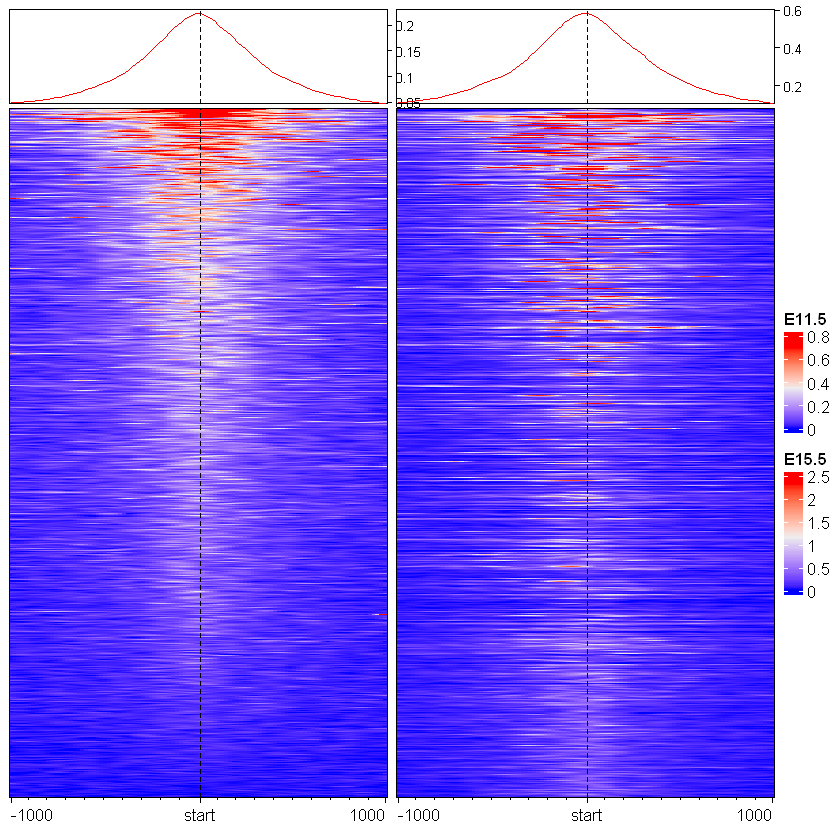

In [18]:
(
  EnrichedHeatmap(mat = mat_AS$ATAC_11half, name = "E11.5")
  +  # joining of different EnrichedHeatmaps
  EnrichedHeatmap(mat = mat_AS$ATAC_15half, name = "E15.5")
)

### Changing color and size

Notice the warning message above about the 1st and 99th percentiles? Most normal ATAC peaks might have a "coverage score" of around 20 to 100 reads. However, the genome contains a few "extreme" regions (often repeats, artifacts, or super-enhancers) that pull in thousands of reads.

By default, `EnrichedHeatmap` assigns the darkest red color to the absolute highest number in our entire matrix.

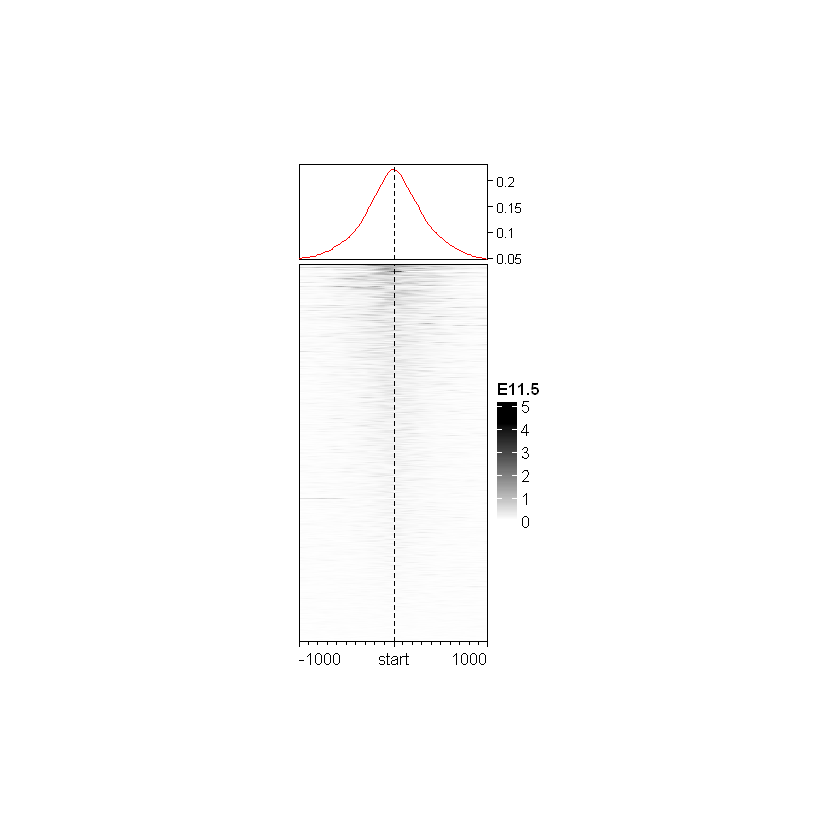

In [19]:
EnrichedHeatmap(
  mat = mat_AS$ATAC_11half,       # normalized matrix
  name = "E11.5",                 # Name for the plot
  # col = c("yellow", "black"),   # Colors for low to high values
  col = c("#ffffff", "black"),  # Colors for low to high values
  width = unit(4, "cm"),          # Width of the heatmap
  height = unit(8, "cm")          # Height of the heatmap
)

### Color based on quantile

Because that maximum number is so ridiculously high, the color scale is stretched too far. All of our normal, biologically real peaks (the 20-100 values) get squashed into the bottom 1% of the color scale, making the entire plot look washed out and white.

We can fix it by **capping** the color scale at the 99th percentile. Instead of letting a few extreme peaks with 5,000 reads wash out the color scale, we cap the darkest red at 100 reads. Any region with more than 100 reads is just colored dark red, revealing the contrast in our normal peaks.

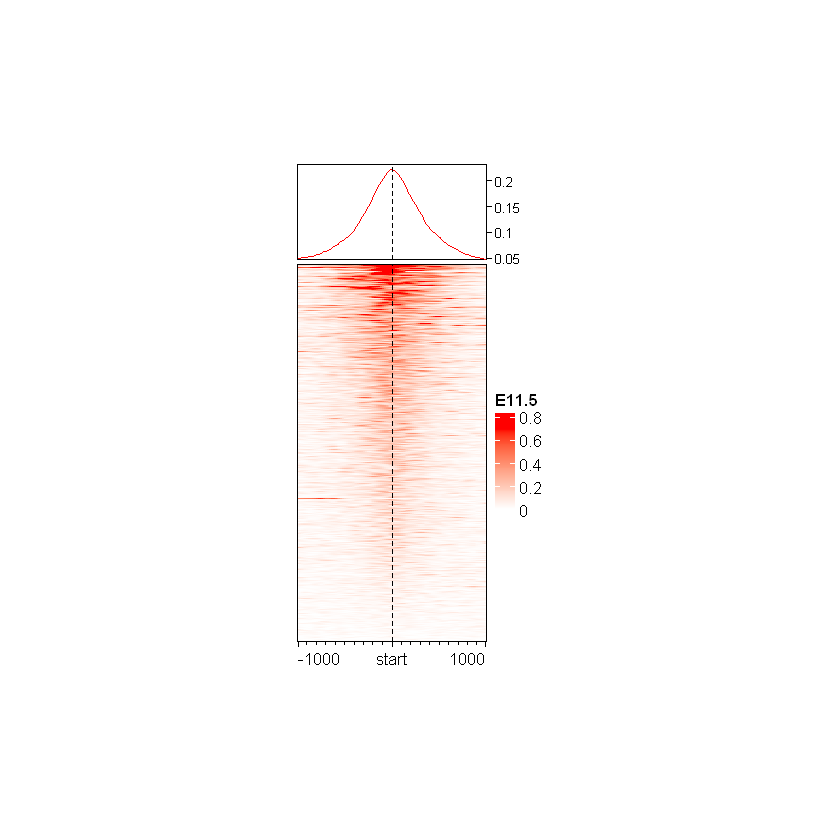

In [20]:
# Taking data between 1 and 99 percentile
col_fun <- colorRamp2(
  quantile(mat_AS$ATAC_11half, c(0.01, 0.99)),
  c("white", "red"))

EnrichedHeatmap(
  mat = mat_AS$ATAC_11half,
  name = "E11.5",
  col = col_fun,
  width = unit(4, "cm"),
  height = unit(8, "cm")
)

There are two main reasons why the dark red signal is shifted to the left (upstream) and isn't perfectly anchored at the mid line:

1. Earlier we used `gr.mid()` to find the exact mathematical center of the peaks. However, `rd_atac` is a consensus peak list (meaning peaks from E11.5 and E15.5 were merged together to make a unified map). If we merge two overlapping peaks, the mathematical midpoint of that new giant region is usually not the same as the biological summit (the spot with the highest read pile-up) for our specific sample. For the E11.5 sample, the actual "hottest" part of the open chromatin just happened to be on the left side of that merged mathematical window.
2. Chromatin accessibility is rarely a perfect, symmetrical bell curve. If a peak is at a promoter, the transcription machinery (like RNA Polymerase) and the +1 nucleosome push the open DNA into an asymmetrical shape. But if a Transcription Factor (TF) is bound to the DNA, the ATAC-seq enzyme (Tn5) cannot cut exactly where the protein is sitting. It has to cut on the sides of it. If the TF is bound slightly off-center, we will see a heavy red signal shifted to one side.

### Customizing heatmap aesthetics for publication

Now that we have fixed our color scale, we can upgrade the rest of the plot from a default visual into a publication-ready figure. In the code block below, we are applying several aesthetic tweaks to make the data much easier to read:

* Cleaning up the legend (`heatmap_legend_param`): instead of letting R guess the legend ticks, we mathematically calculate the 1st percentile, the 99th percentile, and the exact midpoint. We then force the legend to display only these three clean, rounded numbers.
* Biological x-axis (`axis_name`): we replace the default mathematical bin coordinates with clear biological labels (`-1kb`, `mid`, `1kb`).
* Adding a summary profile (`top_annotation`): we add a line plot to the very top of the heatmap using `anno_enriched()`. This incredibly useful annotation displays the *average* signal across all peaks, giving us a quick bird's-eye view of the chromatin accessibility profile. 
* General polishing: we lock in the exact height and width of the heatmap, adjust font sizes so they aren't visually overwhelming, and add a subtle background color to our column title.

_Note that when creating complex figures like heatmaps in a Jupyter Notebook, we might notice that the output sometimes looks squashed, the text overlaps, or the legends get cut off at the edges. This happens because Jupyter has a default, invisible *"canvas"* size (usually 7×7 inches) that it uses to draw all plots. Because ComplexHeatmap is an advanced package designed for publication, it tries to draw elements using strict physical dimensions (e.g., forcing a column to be exactly 3 mm wide). If the total size of our heatmap doesn't match Jupyter's default 7x7 canvas, the final image gets distorted to make it fit. To fix this, we can explicitly tell the notebook's plotting engine to change the size of the "paper" it is drawing on to perfectly frame our heatmap._

In [21]:
# Change Jupyter's global canvas size (measured in inches)
options(repr.plot.width = 3.5, repr.plot.height = 4.5)

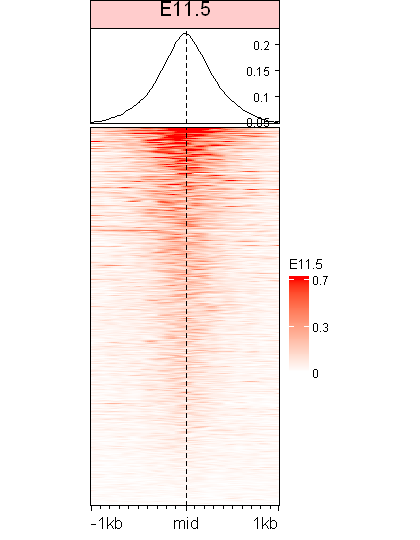

In [22]:
# We first change the color legend to display only 3 values
vmin <- as.numeric(quantile(mat_AS$ATAC_11half, c(0.01)))
vmax <- as.numeric(quantile(mat_AS$ATAC_11half, c(0.99)))
vmid <- (vmin + vmax) / 2
legend_ticks <- c(vmin, vmid, vmax)

EnrichedHeatmap(
  mat = mat_AS$ATAC_11half,
  name = "E11.5",
  col = col_fun,  # re-use the previous custom colormap
  width = unit(4, "cm"),
  height = unit(8, "cm"),
  column_title = "E11.5",
  column_title_gp = gpar(  # 'gp' and `gpar` for graphic parameter
    fontsize = 12,
    fill = "#ffcccc"),
  axis_name = c("-1kb", "mid", "1kb"),
  heatmap_legend_param = list(
    at = legend_ticks,
    labels = round(legend_ticks, digits = 1),
    title_gp = gpar(fontsize = 8),
    labels_gp = gpar(fontsize = 7)
  ),
  top_annotation = HeatmapAnnotation(
    lines = anno_enriched(
      height = unit(2, "cm"),
      gp = gpar(
        lwd = 0.7,
        fontsize = 5),
      axis_param = list(
        side = "right",
        facing = "inside",
        gp = gpar(
          fontsize = 7,
          col = "black",
          lwd = 0.4
        )
      )
    )
  )
)

## Splitting and clustering

### Stratifying the heatmap by direction of change

Right now, all of our ATAC peaks are bundled together. While we can clearly see a general peak of accessibility at the center, this single block hides the dynamic changes occurring between our experimental conditions.

To get a better understanding of the biology, we will use our `logFC` values to split the heatmap into two distinct clusters: regions that *gained accessibility* and regions that *lost accessibility*. This allows us to visually confirm our statistical results and track how different parts of the genome behave.

In [23]:
split_change <- ifelse(
  mid_peaks$ATAC_logFC > 0,
  yes = "Increased accessibility", # TRUE
  no  = "Decreased accessibility")

names(split_change) <- names(mid_peaks)

str(split_change)

 Named chr [1:1933] "Increased accessibility" "Increased accessibility" ...
 - attr(*, "names")= chr [1:1933] "peak_1" "peak_2" "peak_3" "peak_4" ...


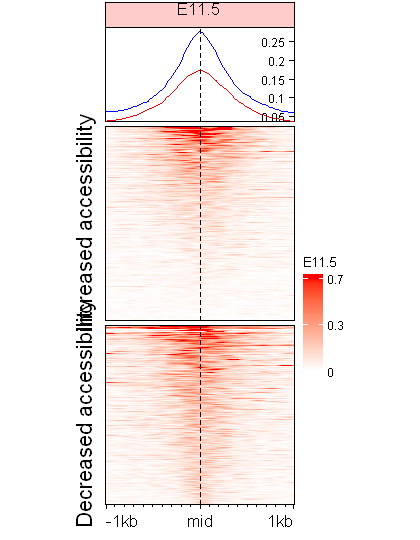

In [24]:
# Define cluster colors
cluster_colors <- c(
  "Increased accessibility" = "red",
  "Decreased accessibility" = "blue")

# Make sure split_change has levels matching the color names
split_change <- factor(
  split_change,
  levels = names(cluster_colors))

EnrichedHeatmap(
  mat = mat_AS$ATAC_11half,
  name = "E11.5",
  row_split = split_change,
  col = col_fun,
  width = unit(4, "cm"),
  height = unit(8, "cm"),
  column_title = "E11.5",
  column_title_gp = gpar(
    fontsize = 10,
    fill = "#ffcccc"),
  axis_name = c("-1kb", "mid", "1kb"),
  heatmap_legend_param = list(
    at = legend_ticks,
    labels = round(legend_ticks, digits = 1),
    title_gp = gpar(fontsize = 8),
    labels_gp = gpar(fontsize = 7)
  ),
  top_annotation = HeatmapAnnotation(
    lines = anno_enriched(
      gp = gpar(col = cluster_colors),
      height = unit(2, "cm"),
      axis_param = list(
        side = "right",
        facing = "inside",
        gp = gpar(
          fontsize = 7,
          lwd = 0.4
        )
      )
    )
  )
)

### Setting categorical levels with factor()

`ComplexHeatmap` is very smart, but if the data order doesn't match our color order, the package can sometimes get confused when building the row annotations and legends.

By default, if we give R raw text, it will almost always sort it alphabetically. Because "Decreased" starts with D and "Increased" starts with I, R's default behavior is to put "Decreased accessibility" at the very top of the heatmap and legend.

The `factor()` function takes raw text and converts it into a strict **categorical** variable. If we simply passed the raw text, R would automatically do this conversion for us under the hood, but it would blindly sort the categories alphabetically (putting 'Decreased' before 'Increased')

By manually setting `levels = names(cluster_colors)`, we prevent R from guessing the layout. We are telling R that the strict, *permanent order* of these categories is exactly the order we defined in our color list. We explicitly used factor() to override the alphabet and force 'Increased' to the top of our heatmap.

## Functional programming

### Creating a reusable heatmap function

Because we have multiple samples to analyze, copying and pasting that massive block of plotting code is inefficient. Instead, it is best practice to wrap our code into a custom `function` so we can easily generate matching heatmaps for any dataset.

In [25]:
make_EH <- function(
  norm_mat,
  hm_name,
  split_rows = NULL,
  heatmap_cols = c("white", "red"),
  col_fill = "#ffcccc",
  line_colors = cluster_colors) {
  
  # 1. Define color scale based on 1st and 99th percentiles
  col_fun <- colorRamp2(
    quantile(norm_mat, c(0.01, 0.99)),
    heatmap_cols)
  
  # 2. Calculate ticks for the legend
  vmin <- as.numeric(quantile(norm_mat, c(0.01)))
  vmax <- as.numeric(quantile(norm_mat, c(0.99)))
  vmid <- (vmin + vmax) / 2
  legend_ticks <- c(vmin, vmid, vmax)

  # 3. Generate and return the heatmap
  EnrichedHeatmap(
    mat = norm_mat,
    name = hm_name,
    row_split = split_rows,
    col = col_fun,
    width = unit(4, "cm"),
    height = unit(8, "cm"),
    column_title = hm_name,
    column_title_gp = gpar(fontsize = 10, fill = col_fill),
    axis_name = c("-1kb", "mid", "1kb"),
    heatmap_legend_param = list(
      at = legend_ticks,
      labels = round(legend_ticks, digits = 1),
      title_gp = gpar(fontsize = 8),
      labels_gp = gpar(fontsize = 7)
    ),
    top_annotation = HeatmapAnnotation(
      lines = anno_enriched(
        gp = gpar(col = line_colors),
        height = unit(2, "cm"),
        axis_param = list(
          side = "right",
          facing = "inside",
          gp = gpar(
            fontsize = 7,
            lwd = 0.4
          )
        )
      )
    )
  )
}

### Making EnrichedHeatmaps for both ATAC samples

Importantly, this allows us to generate independent `EnrichedHeatmap` objects for each sample. Once we have those individual objects, we can easily concatenate them and use the `draw()` function to plot them beautifully side-by-side.

In [26]:
eh_11h <- make_EH(
  norm_mat = mat_AS$ATAC_11half,
  split_rows = split_change,
  hm_name = "E11.5")

eh_15h <- make_EH(
  norm_mat = mat_AS$ATAC_15half,
  split_rows = split_change,
  hm_name = "E15.5",
  col_fill = "#87cefa")

### Resetting the canvas for larger plots

Remember the `options()` command we used earlier to shrink our Jupyter canvas? Because that was a global setting, our notebook is currently stuck drawing on a tiny 3.5 x 4.5 inch piece of "paper".

Now that we are combining multiple heatmaps and annotations into one large, unified figure, that tiny canvas is far too small. Before we generate this larger figure, we must reset the canvas back to its default.

In [27]:
# Reset Jupyter plot dimensions to the standard defaults (7x7 inches)
options(repr.plot.width = 7, repr.plot.height = 7)

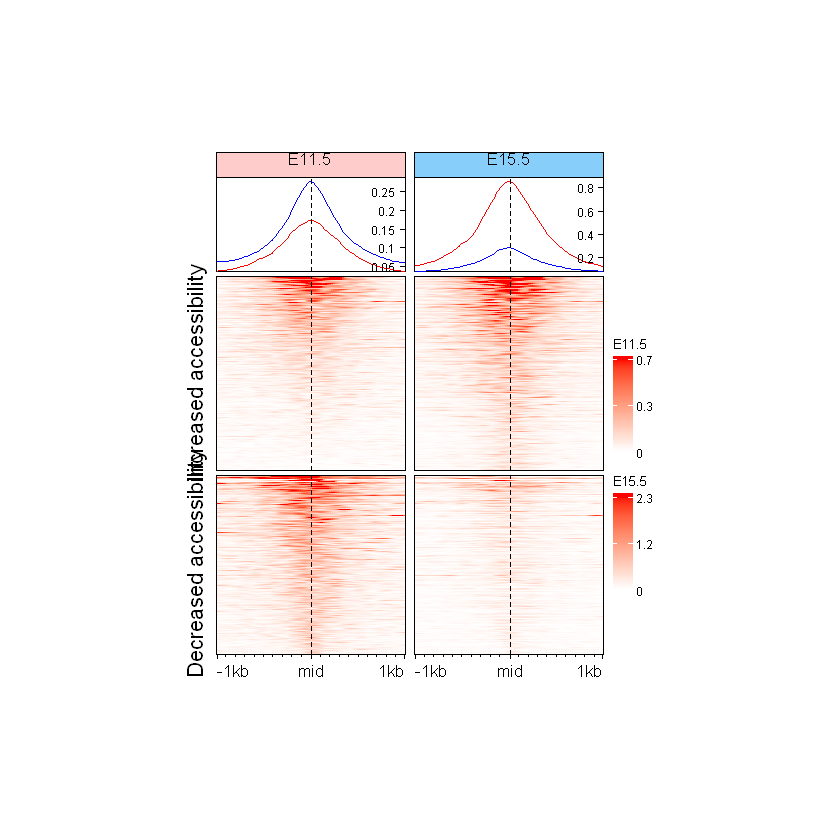

In [28]:
draw(eh_11h + eh_15h, merge_legend = TRUE)

By default, `ComplexHeatmap` appoints the first heatmap in the list as the "Main Heatmap". Because `eh_11h` is the Main Heatmap here, it calculates the row order based on its signal intensity, and `eh_15h` is automatically forced to obey that exact order.

## Combining multiple heatmaps

### Generating the unified heatmaps and annotations

First, we will use our new `make_EH()` function to generate the heatmaps for both our E11.5 and E15.5 samples. Notice that we are intentionally leaving out the `split_rows` argument (letting it default to `NULL`). By removing this split, the heatmaps will initially generate as simple, continuous blocks rather than breaking into separate clusters.

Next, we want to *label* which peaks belong to which cluster. To make this visually intuitive, we will build a tiny, 3-millimeter wide *"mini-heatmap"* to act as a colored side-bar, making sure to reuse our exact `cluster_colors` palette to maintain visual consistency.

Finally, we can glue our samples and this new color bar together into a single figure. But how do we get our biological clusters back? Instead of trying to split each heatmap individually (which can cause frustrating alignment errors), we use a function of the `ComplexHeatmap` package: the `draw()` function. By passing our `split_change` groups directly into `draw()`, it acts as a global master controller, seamlessly splitting the entire combined figure in one shot.

In [29]:
eh_11h <- make_EH(
  norm_mat = mat_AS$ATAC_11half,
  # split_rows = NULL,
  hm_name = "E11.5")

eh_15h <- make_EH(
  norm_mat = mat_AS$ATAC_15half,
  hm_name = "E15.5",
  col_fill = "#e6fff2")

row_order_eh <- row_order(eh_11h)

anno_hm <- Heatmap(
  split_change,
  # col = c("red", "blue"),
  col = cluster_colors,  # key-to-value color mapping
  name = "Change",
  show_row_names = FALSE,
  show_column_names = FALSE,
  width = unit(3, "mm"),
  height = unit(8, "cm"),
  row_order = row_order_eh,
  # row_title_gp = gpar(fontsize = 0),  # still showing 1-px text
  row_title = NULL
)

Warning message:
"The heatmap has not been initialized. You might have different results
if you repeatedly execute this function, e.g. when row_km/column_km was
set. It is more suggested to do as `ht = draw(ht); row_order(ht)`."


### Named vectors vs. simple vectors for colors

Because our side-bar annotation represents **discrete values** (a peak is strictly either "Increased" or "Decreased"), we must be careful about how we assign colors. Rather than passing a simple list of colors like `c("red", "blue")`, we pass our `cluster_colors` variable, which is a **named vector** (a dictionary).

According to the [official ComplexHeatmap documentation](https://jokergoo.github.io/ComplexHeatmap-reference/book/a-single-heatmap.html#colors):

> *"If the matrix contains discrete values (either numeric or character), colors should be specified as a named vector to make it possible for the mapping from discrete values to colors. If there is no name for the color vector, the order of colors corresponds to the order of `unique(mat)`."*

By using our named vector, we mathematically lock the exact text keys to their specific colors, ensuring that "Increased" is always red and "Decreased" is always blue.

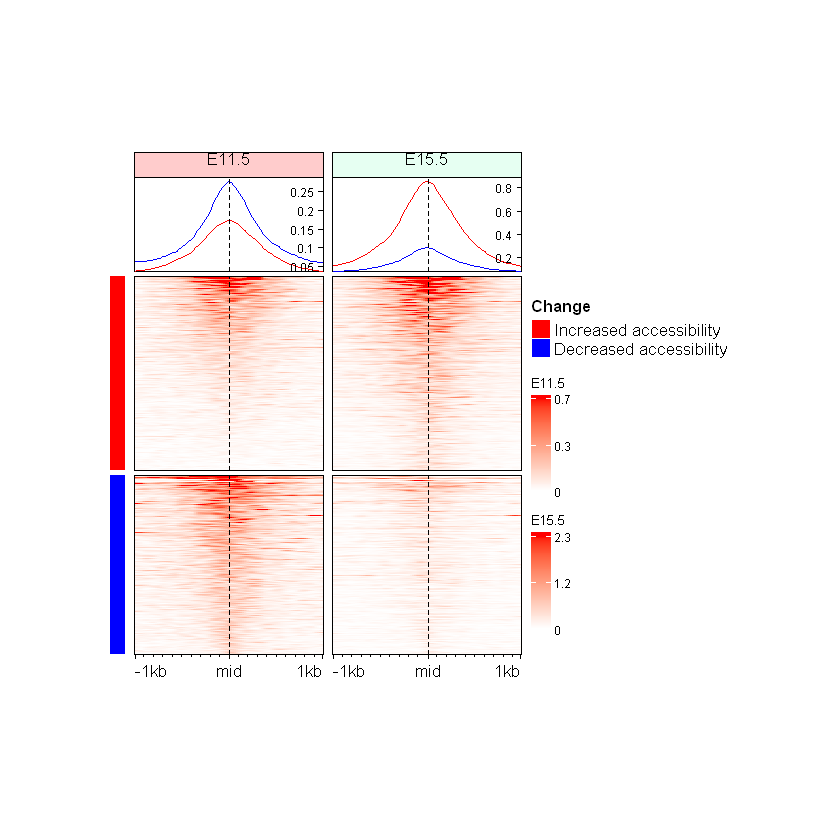

In [30]:
draw(
  anno_hm + eh_11h + eh_15h,
  split = split_change,
  merge_legend = TRUE)

Standard `Heatmap()` always try to cluster (sort) their data by default. When we attached `anno_hm` to the plot, it started trying to sort the rows based on the text. By explicitly passing `row_order_eh` to the mini-heatmap, we "locked" it, forcing it to stop trying to sort itself and to just perfectly mirror the Main Heatmap, i.e. `eh_11h`.

_Note that we can also just pass `cluster_rows = FALSE` into `anno_hm` and remove `row_order = row_order_eh`, and then use `draw(anno_hm + eh_11h + eh_15h, main_heatmap = "E11.5")`, or use `rowAnnotation()` instead (discussed at the end of the notebook) to achieve the exact same result._

## Question 1

**Can you make split the Enriched Heatmap based on the annotations?**

**_Hint:_** `mid_peaks$ATAC_anno` contain annotations for the regions. 

In [31]:
mid_peaks

GRanges object with 1933 ranges and 18 metadata columns:
            seqnames    ranges strand |        ATAC_annotation ATAC_geneChr
               <Rle> <IRanges>  <Rle> |            <character>    <integer>
     peak_1     chr1   3671606      * |       Promoter (<=1kb)            1
     peak_2     chr1   4332610      * | Intron (ENSMUST00000..            1
     peak_3     chr1   4492164      * |       Promoter (1-2kb)            1
     peak_4     chr1   4571804      * |      Distal Intergenic            1
     peak_5     chr1   4785693      * |       Promoter (<=1kb)            1
        ...      ...       ...    ... .                    ...          ...
  peak_1929     chr2 181713883      * |       Promoter (<=1kb)            2
  peak_1930     chr2 181715203      * |       Promoter (<=1kb)            2
  peak_1931     chr2 181763479      * |       Promoter (<=1kb)            2
  peak_1932     chr2 181764777      * |       Promoter (1-2kb)            2
  peak_1933     chr2 181837949 

In [32]:
head(mid_peaks$ATAC_anno, 10)

[1] "Promoter"   "Intron"     "Promoter"   "Intergenic" "Promoter"  
 [6] "Intergenic" "Promoter"   "Promoter"   "Promoter"   "Intergenic"

In [33]:
# Extract the genomic annotations (e.g., "Promoter", "Intron", "Intergenic") 
# from the peak metadata and save it as a standalone vector.
split_anno <- mid_peaks$ATAC_anno

# Attach the original peak IDs as names to this new vector. 
# This ensures every annotation label stays permanently linked to its peak
names(split_anno) <- names(mid_peaks)

head(split_anno)

peak_1       peak_2       peak_3       peak_4       peak_5       peak_6 
  "Promoter"     "Intron"   "Promoter" "Intergenic"   "Promoter" "Intergenic"

Instead of building a new dataframe from scratch, we may simply extract the `GRanges` object's metadata table (`mcols`) as a standard dataframe and slice out the exact column we want. Because we are slicing the existing table, R automatically brings the peak IDs along as our row names.

_Note: `mcols()` returns a **`DataFrame`** (with a capital D and F), which is a highly complex, specialized object built by Bioconductor to hold biological data types (like raw DNA sequences) that a normal table cannot hold. However, visualization packages expect R's standard, universally accepted **`data.frame`**. Therefore, we must use `as.data.frame()` here to safely convert our heavy genomic object into a lightweight table that the heatmap can easily understand._

In [34]:
# Extract the metadata as a dataframe, and slice the specific column 
# (drop = FALSE ensures it stays a 2D dataframe instead of collapsing)
split_anno_df <- as.data.frame(
  mcols(mid_peaks))[, "ATAC_anno", drop = FALSE]

head(split_anno_df)

,ATAC_anno
,<chr>
peak_1,Promoter
peak_2,Intron
peak_3,Promoter
peak_4,Intergenic
peak_5,Promoter
peak_6,Intergenic


However, in base R, when we pull a column out of a data frame or a `GRanges` object (`split_anno_df$ATAC_anno`), R stubbornly strips off the row names and just hands us a flat, nameless vector. To build a "Series" in base R, we have to manually map the index back onto the vector...

In [35]:
head(split_anno_df$ATAC_anno)

[1] "Promoter"   "Intron"     "Promoter"   "Intergenic" "Promoter"  
[6] "Intergenic"

In [36]:
# Dynamically generate a distinct color palette for all the distinct categories
anno_colors <- RColorBrewer::brewer.pal(n = length(unique(split_anno)), name = "Set1")

names(anno_colors) <- sort(unique(split_anno))

anno_an <- Heatmap(
  split_anno,
  col = anno_colors,
  name = "anno",
  show_row_names = FALSE,
  show_column_names = FALSE,
  width = unit(3, "mm"),
  height = unit(8, "cm"),
  cluster_rows = FALSE,
  row_title = NULL
)

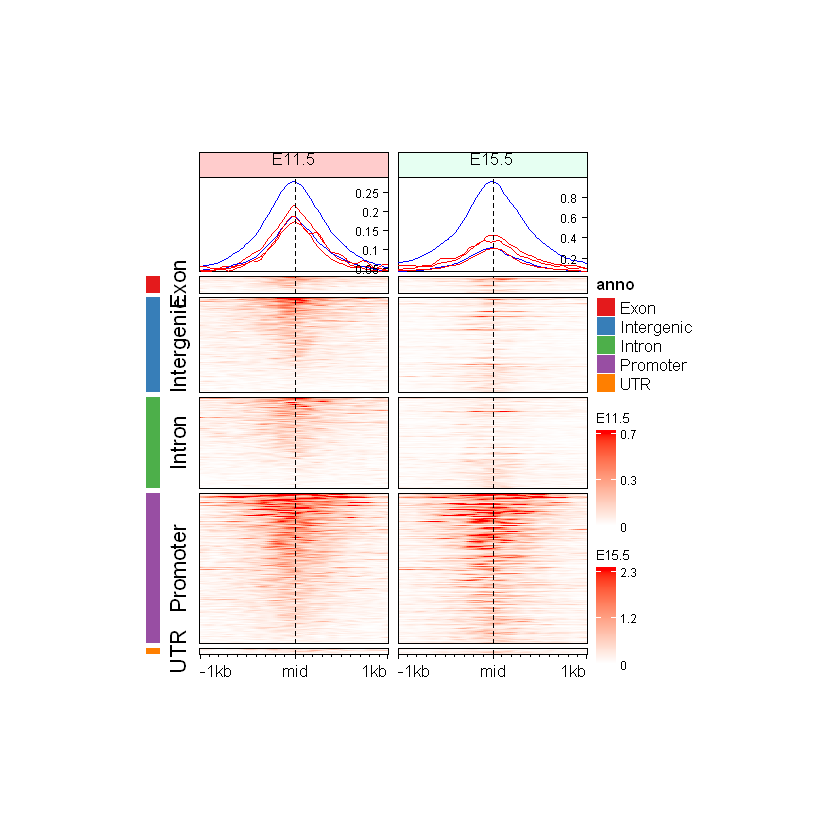

In [37]:
draw(anno_an + eh_11h + eh_15h, split = split_anno, main_heatmap = "E11.5", merge_legend = TRUE)

## Refining the custom heatmap function

If we look closely at the summary profile at the top of our previous heatmaps, it only displayed two lines (Red and Blue), which perfectly represented the aggregate signal for our "Increased" and "Decreased" clusters.

However, by splitting our heatmap by Direction and/or Genomic Region, we create multiple distinct sub-clusters. Consequently, the top `anno_enriched()` profile will now attempt to calculate and display overlapping lines for every specific sub-cluster combination.

Because our `make_EH()` function explicitly passes `gp = gpar(col = cluster_colors)` to the top annotation, `EnrichedHeatmap` will be forced to **recycle colors**, trying to draw many lines using only our two predefined colors. To fix this, we will update our custom function to make the `line_colors` argument **optional** (defaulting to `NULL`). This gives us the flexibility to dynamically pass a *custom colormap* that perfectly matches the exact number of clusters we are analyzing.

Additionally, we must address a frustrating quirk in how the package handles text labels. When we pass our `split_anno_df` to the global `draw()` function, it automatically generates text labels for every single cluster combination. It then forcefully hands these text labels down to our Main Heatmap (`eh_11h`) and tells it to print them. 

Putting `row_title = NULL` inside `draw()` only hides the *global* title for the entire figure; it does nothing to hide these individual slice titles. To truly remove this text clutter and let our color bars do the talking, we must tell the heatmap object itself to reject them. We will do this by adding `row_title = NULL` directly into our `make_EH()` function, and then we will quickly regenerate our heatmaps.

In [38]:
# Upgraded version of the original custom function
make_EH2 <- function(
  norm_mat,
  hm_name,
  split_rows = NULL,
  heatmap_cols = c("white", "red"),
  col_fill = "#ffcccc",
  line_colors = NULL  # make it optional for more flexible splits
) {
  
  # Define color scale based on 1st and 99th percentiles
  col_fun <- colorRamp2(
    quantile(norm_mat, c(0.01, 0.99)),
    heatmap_cols)
  
  # Calculate ticks for the legend
  vmin <- as.numeric(quantile(norm_mat, c(0.01)))
  vmax <- as.numeric(quantile(norm_mat, c(0.99)))
  vmid <- (vmin + vmax) / 2
  legend_ticks <- c(vmin, vmid, vmax)

  # Generate and return the heatmap
  EnrichedHeatmap(
    mat = norm_mat,
    name = hm_name,
    row_split = split_rows,
    row_title = NULL,  # remove cluster row text
    col = col_fun,
    width = unit(4, "cm"),
    height = unit(8, "cm"),
    column_title = hm_name,
    column_title_gp = gpar(fontsize = 10, fill = col_fill),
    axis_name = c("-1kb", "mid", "1kb"),
    heatmap_legend_param = list(
      at = legend_ticks,
      labels = round(legend_ticks, digits = 1),
      title_gp = gpar(fontsize = 8),
      labels_gp = gpar(fontsize = 7)
    ),
    top_annotation = HeatmapAnnotation(
      lines = anno_enriched(
        gp = gpar(col = line_colors),
        height = unit(2, "cm"),
        axis_param = list(
          side = "right",
          facing = "inside",
          gp = gpar(
            fontsize = 7,
            lwd = 0.4
          )
        )
      )
    )
  )
}

In [39]:
# Create two new ComplexHeatmap objects with the updated custom function
eh_11h2 <- make_EH2(
  norm_mat = mat_AS$ATAC_11half,
  line_colors = anno_colors,
  hm_name = "E11.5")

eh_15h2 <- make_EH2(
  norm_mat = mat_AS$ATAC_15half,
  line_colors = anno_colors,
  hm_name = "E15.5",
  col_fill = "#e6fff2")

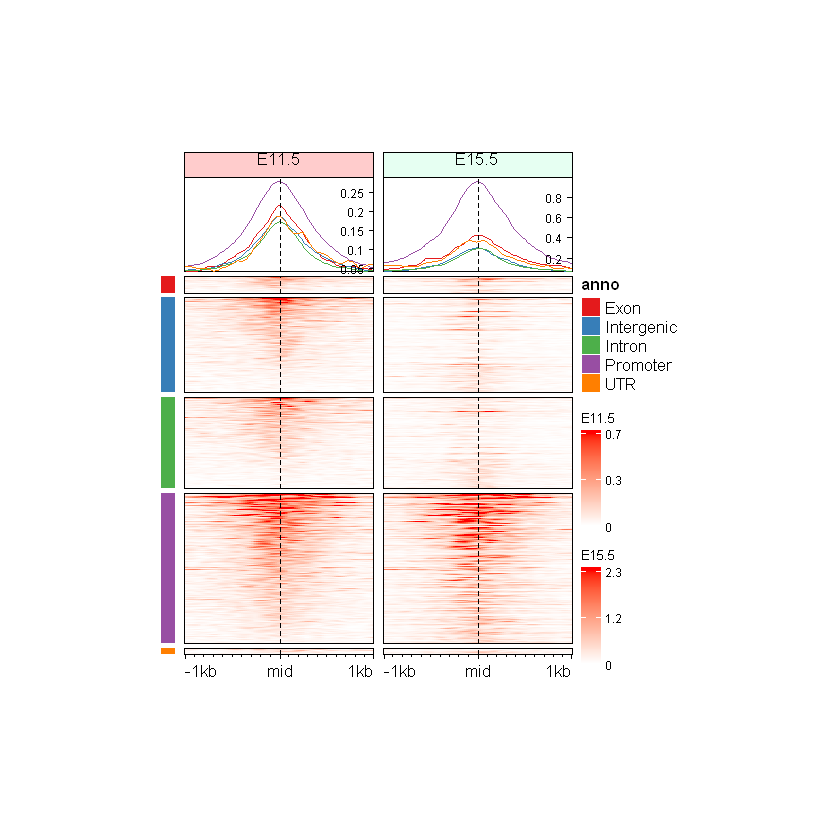

In [40]:
draw(anno_an + eh_11h2 + eh_15h2, split = split_anno, main_heatmap = "E11.5", merge_legend = TRUE)

## Question 2

**Can you make split the Enriched Heatmap based on the annotations and change in direction?**

**_Hint:_** `mid_peaks$ATAC_anno` contain annotations for the regions. `mid_peaks$ATAC_logFC` contain sign of change.

In [41]:
split_anno_dir <- paste(
  mid_peaks$ATAC_anno, ifelse(
    mid_peaks$ATAC_logFC > 0,
    yes = "Inc",
    no = "Dec"))
# paste() destroys the factor() levels we built earlier. Moreover, we create 6 brand new 
# categories ("Promoter Inc", "Promoter Dec", etc.). If we keep them separate, we can just
# stitch the two existing 3mm color bars side-by-side, as shown in the next question.

names(split_anno_dir) <- names(mid_peaks)

head(split_anno_dir)

peak_1           peak_2           peak_3           peak_4 
  "Promoter Inc"     "Intron Inc"   "Promoter Dec" "Intergenic Dec" 
          peak_5           peak_6 
  "Promoter Inc" "Intergenic Dec"

In [42]:
cols_an <- RColorBrewer::brewer.pal(
  n = length(unique(split_anno_dir)),
  name = "Paired")

# Create two new ComplexHeatmap objects with the updated custom function
eh_11h3 <- make_EH2(
  norm_mat = mat_AS$ATAC_11half,
  line_colors = cols_an,
  hm_name = "E11.5")

eh_15h3 <- make_EH2(
  norm_mat = mat_AS$ATAC_15half,
  line_colors = cols_an,
  hm_name = "E15.5",
  col_fill = "#e6fff2")

anno_an_dir <- Heatmap(
  split_anno_dir,
  col = cols_an,
  name = "anno",
  show_row_names = FALSE,
  show_column_names = FALSE,
  width = unit(3, "mm"),
  height = unit(8, "cm"),
  row_order = row_order_eh,
  row_title = NULL
)

There are 10 unique colors in the vector `col` and 10 unique values in
`matrix`. `Heatmap()` will treat it as an exact discrete one-to-one
mapping. If this is not what you want, slightly change the number of
colors, e.g. by adding one more color or removing a color.



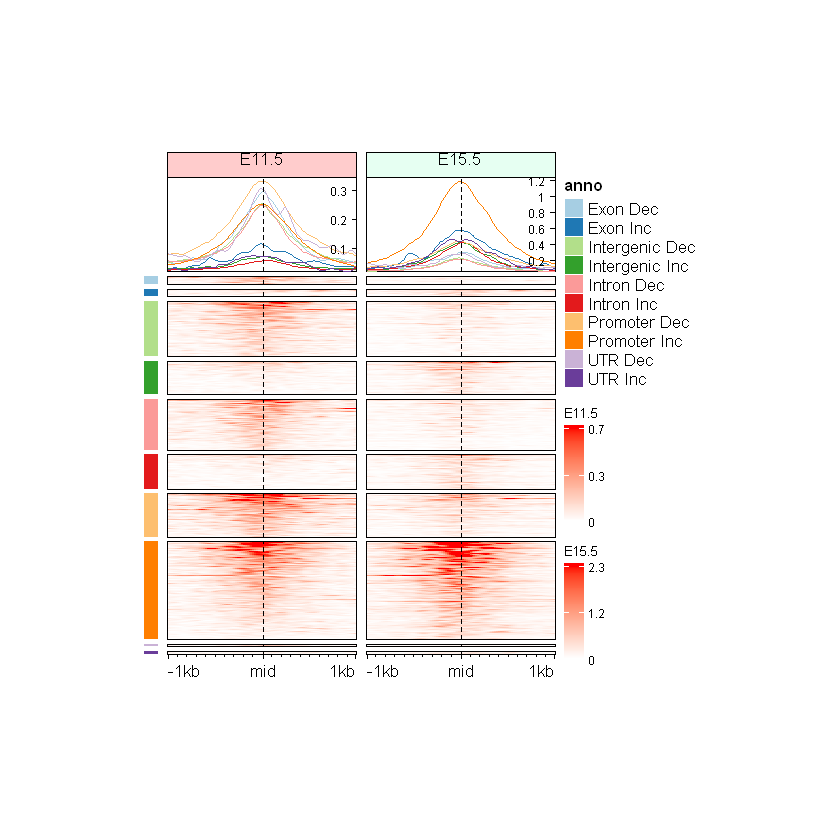

In [43]:
draw(anno_an_dir + eh_11h3 + eh_15h3, split = split_anno_dir, merge_legend = TRUE)

## Question 3

**Can you make split the Enriched Heatmap based on the annotations and change in direction with separate color bars for annotation and direction of change?**

### The "Mini-Heatmap" method

To make this two-level split work while keeping our top profile lines colored strictly by Direction, we must generate brand new ATAC heatmap objects using the updated version of our custom function. Creating new objects allows us to pass the correct color dictionary and ensure no messy auto-generated slice text appears on the plot. Furthermore, we must explicitly set the `main_heatmap` argument inside our `draw()` function to prevent the mini-heatmaps from hijacking the layout and causing a sorting "tug-of-war."

In [44]:
# Combine our two existing variables into a single data frame
split_anno_df <- data.frame(
  Annotation = mid_peaks$ATAC_anno,
  Direction = ifelse(mid_peaks$ATAC_logFC > 0, yes = "Inc", no = "Dec")
)

head(split_anno_df)

,Annotation,Direction
,<chr>,<chr>
1,Promoter,Inc
2,Intron,Inc
3,Promoter,Dec
4,Intergenic,Dec
5,Promoter,Inc
6,Intergenic,Dec


In [45]:
annot_colors <- c(
  "red", "blue", RColorBrewer::brewer.pal(
    n = length(unique(split_anno_df$Annotation)), name = "Set1"))

names(annot_colors) <- c(unique(split_anno_df$Direction), unique(split_anno_df$Annotation))

annot_colors

Inc        Dec   Promoter     Intron Intergenic       Exon        UTR 
     "red"     "blue"  "#E41A1C"  "#377EB8"  "#4DAF4A"  "#984EA3"  "#FF7F00"

In [46]:
# Define cluster colors
cluster_colors_short <- c(
  "Inc" = "red",
  "Dec" = "blue")

# Another heatmaps with top line colored by Direction
eh_11h2_dir <- make_EH2(
  norm_mat = mat_AS$ATAC_11half,
  line_colors = cluster_colors_short,
  hm_name = "E11.5")

eh_15h2_dir <- make_EH2(
  norm_mat = mat_AS$ATAC_15half,
  line_colors = cluster_colors_short,
  hm_name = "E15.5",
  col_fill = "#e6fff2")

anno_an_df <- Heatmap(
  split_anno_df,
  name = "anno",
  col = annot_colors,
  show_row_names = FALSE,
  show_column_names = FALSE,
  width = unit(3, "mm"),
  height = unit(8, "cm"),
  cluster_rows = FALSE,
  row_title = NULL
)

Warning message:
"The input is a data frame-like object, convert it to a matrix."
Warning message:
"Note: not all columns in the data frame are numeric. The data frame
will be converted into a character matrix."


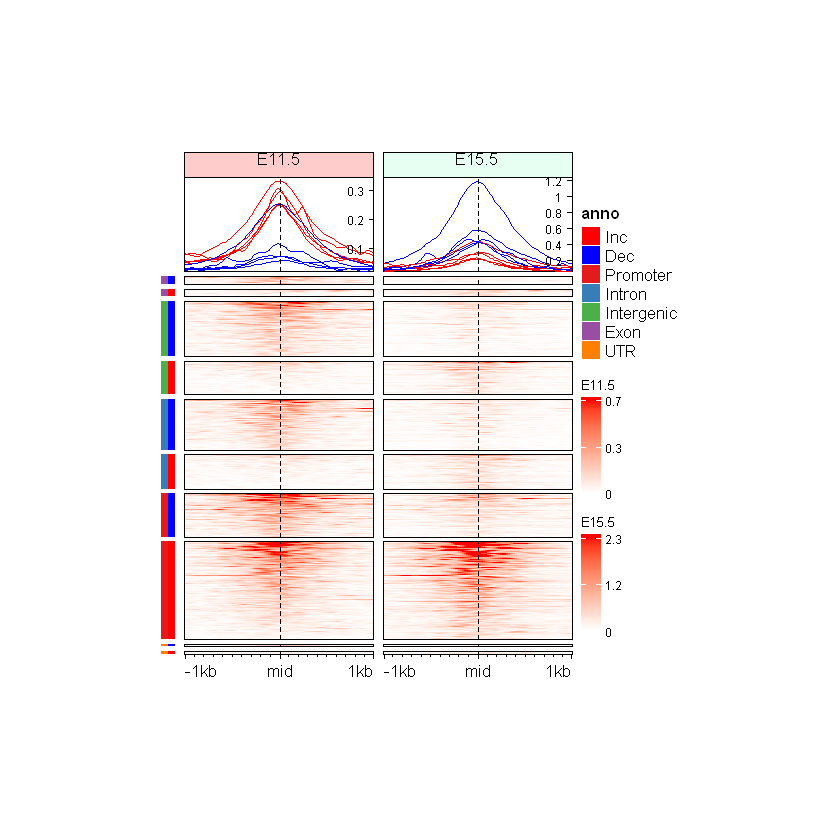

In [47]:
ht <- draw(
  anno_an_df + eh_11h2_dir + eh_15h2_dir,
  main_heatmap = "E11.5",
  split = split_anno_df,
  merge_legend = TRUE)

ht

If we look closely at the E11.5 heatmap (left), the highest signal is clearly in the "Dec" (Blue) clusters. But the top profile draws those highest peaks in Red! Conversely, E15.5 has intense signal in the "Inc" (Red) clusters, but its top profile draws the highest peaks in Blue. It doesn't correspond to the profiles observed in the previous plots.

Remember `cluster_colors_short` only contains two names ("Inc" and "Dec"). But because our final `draw()` function is going to split the heatmap by two variables (using the dataframe), the top profile is going to ask the dictionary for the color of the squashed string: `"Inc, Promoter"`. Because `"Inc, Promoter"` is not inside `cluster_colors_short`, the heatmap blindly recycles the red and blue colors, scrambling the lines.

In [48]:
# Extract the exact slice names
print(names(row_order(ht)))

 [1] "Exon,Dec"       "Exon,Inc"       "Intergenic,Dec" "Intergenic,Inc"
 [5] "Intron,Dec"     "Intron,Inc"     "Promoter,Dec"   "Promoter,Inc"  
 [9] "UTR,Dec"        "UTR,Inc"       


### The `rowAnnotation` method

Instead of forcing tiny heatmaps to act as labels, `ComplexHeatmap` provides a dedicated [`rowAnnotation()` function](https://www.rdocumentation.org/packages/ComplexHeatmap/versions/1.10.2/topics/rowAnnotation). This is the cleanest, most professional way to annotate complex plots.

By passing our metadata as a `data.frame` along with a list of color dictionaries, the package handles the mapping for multiple variables simultaneously. Best of all, because it is structurally recognized as an "annotation" rather than a heatmap, it never fights for the Main Heatmap role. This keeps our code clean and guarantees our biological sorting remains perfectly intact.

_Note: the visual order of the color bars is dictated entirely by the order of the columns inside the dataframe._

In [49]:
# Similarly using previously created vectors
split_anno_change_df <- data.frame(
  Annotation = split_anno,
  Change = split_change
)

head(split_anno_change_df)

,Annotation,Change
,<chr>,<fct>
peak_1,Promoter,Increased accessibility
peak_2,Intron,Increased accessibility
peak_3,Promoter,Decreased accessibility
peak_4,Intergenic,Decreased accessibility
peak_5,Promoter,Increased accessibility
peak_6,Intergenic,Decreased accessibility


In [50]:
# Let ComplexHeatmap handle the mapping
my_annotations <- rowAnnotation(
  df = split_anno_change_df,
  col = list(  # follow the order of the columns in the dataframe
    Annotation = anno_colors,
    Change = cluster_colors
  ),
  show_annotation_name = FALSE
)


We now pass the `draw()` function the `split_anno_change_df` dataframe with two columns. `ComplexHeatmap` goes row by row and groups the peaks by *every unique combination* of those two variables (e.g., all peaks that are both "Increased" AND "Promoter" get grouped together). It therefore preserves our biological sorting (factors), perfectly syncs with the Color Bars, and calculates the aggregate signal for the top `anno_enriched()` lines much more accurately.

However, because this multi-variable split generates new combined cluster names (like `"Inc, Promoter"`), our original 2-color dictionary is no longer sufficient. To prevent the top profile from blindly recycling colors, we still need to build a custom color dictionary that explicitly maps our red and blue colors to these exact combination strings!

In [51]:
# Generate the exact slice names that ComplexHeatmap will create
# (By default, ComplexHeatmap pastes dataframe columns together separated by ", ")
slice_names <- unique(
  paste(split_anno_change_df$Annotation, split_anno_change_df$Change, sep = ", "))

# Build the TRUE, locked color dictionary
# If the slice name contains "Inc", it gets red. Otherwise, it gets blue.
true_line_colors <- ifelse(
  grepl("Inc", slice_names), "red", "blue")
names(true_line_colors) <- slice_names

# Generate the heatmaps using the foolproof dictionary
eh_11h3_dir <- make_EH2(
  norm_mat = mat_AS$ATAC_11half,
  line_colors = true_line_colors,
  hm_name = "E11.5"
)

eh_15h3_dir <- make_EH2(
  norm_mat = mat_AS$ATAC_15half,
  line_colors = true_line_colors,
  hm_name = "E15.5",
  col_fill = "#e6fff2"
)

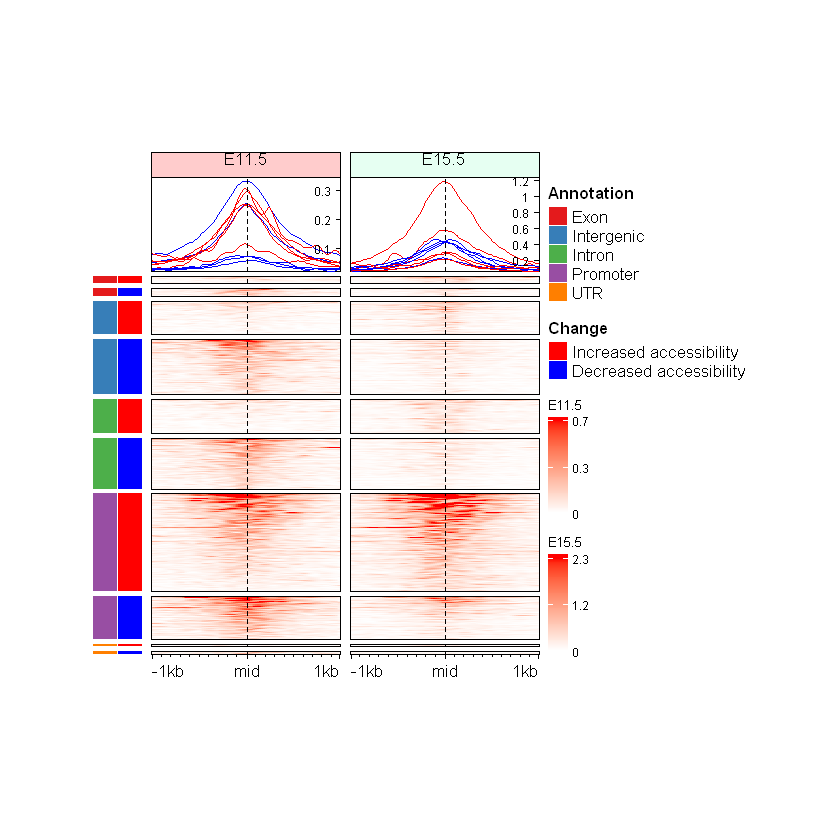

In [52]:
draw(
  my_annotations + eh_11h3_dir + eh_15h3_dir,
  split = split_anno_change_df,
  merge_legend = TRUE)

### The power of native annotations

In our earlier attempts to add a color bar for the direction of change, we used what we can call the "Mini-Heatmap" hack. We created an entirely separate heatmap and forcefully squashed it into a tiny column by hardcoding `width = unit(3, "mm")` inside our code. Because we were forcing exact dimensions, we also had to tightly micromanage the global Jupyter canvas size just to make everything fit.

However, as we just saw, utilizing `ComplexHeatmap`'s native `rowAnnotation()` function changes everything. `rowAnnotation()` is specifically designed for this exact purpose. It natively understands how to size itself, how to align with the main heatmap rows, and how to format its own legends without us having to write hacky dimensional constraints.

What does this mean for our code moving forward? It means we can go back to our custom `make_EH()` function and remove the hardcoded width and height definitions entirely. By letting `rowAnnotation()` handle the side-bars, and letting `ComplexHeatmap`'s layout engine dynamically calculate the sizes of the main plotting areas, our code becomes significantly more flexible. Instead of rigid, hardcoded plots, we now have a highly adaptable pipeline that will automatically scale and look beautiful, whether we are plotting a tiny subset of 100 peaks or a massive multi-omics integration of 50,000 regions.